# Homework 1: Data Collection and Analysis using REST APIs

---

## Introduction

This notebook addresses Homework 1, whose objective is to gain hands-on experience with real-world data collected through REST APIs. The analysis focuses on **air quality in London (Westminster — Marylebone Road station)** over a 6-month period (August 2025 – February 2026).

We integrate data from two public APIs:
1. **OpenAQ** — air quality measurements (PM2.5, PM10, NO₂, O₃, CO, SO₂) from a government reference monitor at Marylebone Road
2. **Open-Meteo** — historical daily weather data (temperature, humidity, wind speed, precipitation) for the same location

The workflow follows the assignment structure:
- **Task 1:** Data collection via REST APIs and local storage
- **Task 2:** Data cleaning, parsing, and integration into a unified dataset
- **Task 3:** Exploratory Data Analysis (summary statistics, time series, correlations)
- **Task 4:** Machine Learning — regression models to predict PM2.5 from weather and pollutant features
- **Task 5:** Evaluation, feature importance, and interpretation of results

---

## Task 1: Data Collection via REST APIs

We begin by collecting the raw data. All API responses are saved locally as JSON files so that subsequent processing does not require repeated API calls.

In [3]:
# Importing libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv
import json
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import statsmodels.api as sm

### 1.1 Weather Data (Open-Meteo API)

We use the [Open-Meteo Archive API](https://open-meteo.com/) to retrieve **daily** weather data for London (Marylebone Road area) from August 2025 to February 2026. The selected variables — temperature, wind speed, precipitation, and relative humidity — are known to influence particulate matter and gaseous pollutant concentrations.

In [4]:
# Coordinates for London - Marylebone Road
weather_url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 51.5225,
    "longitude": -0.1546,
    "start_date": "2025-08-01",
    "end_date": "2026-02-01",
    "daily": [
        "temperature_2m_mean",
        "wind_speed_10m_max",
        "precipitation_sum",
        "relative_humidity_2m_mean"
    ],
    "timezone": "Europe/London"
}

response = requests.get(weather_url, params=params)

if response.status_code == 200:
    weather_data = response.json()
    with open("resources_london/weather_data.json", "w") as f:
        json.dump(weather_data, f, indent=2)
    print("Weather data saved successfully.")
else:
    print("Error:", response.status_code)

Weather data saved successfully.


### 1.2 Air Quality Data (OpenAQ API)

We use the [OpenAQ API (v3)](https://docs.openaq.org/) to collect air quality measurements from the **London Marylebone Road** monitoring station (location ID: `154`). This is a DEFRA (UK government) reference-grade monitor that provides data on six pollutants: PM2.5, PM10, NO₂, O₃, CO, and SO₂.

The API requires authentication via an API key, which we load from a `.env` file to avoid hardcoding credentials in the notebook.

In [5]:
load_dotenv()

api_key = os.getenv("OPENAQ_API_KEY")

if api_key:
    print(f"API key loaded successfully")
else:
    print("WARNING: API key not found. Make sure OPENAQ_API_KEY is set in your .env file.")

headers = {"X-API-Key": api_key}

API key loaded successfully


We first query the `/locations` endpoint to retrieve the station metadata, including the list of available sensors and their IDs.

In [6]:
url = "https://api.openaq.org/v3/locations/154"

response = requests.get(url, headers=headers)

if response.status_code == 200:
    data = response.json()
    station = data["results"][0]

    print(f"Station: {station['name']}")
    print(f"Country: {station['country']['name']}")
    print(f"Locality: {station['locality']}")
    print(f"Provider: {station['provider']['name']}")
    print(f"Coordinates: {station['coordinates']}")
    print(f"Data available from {station['datetimeFirst']['local']} to {station['datetimeLast']['local']}")
    print(f"\nAvailable sensors:")
    for s in station["sensors"]:
        print(f"  - {s['parameter']['displayName']} ({s['parameter']['units']}) → sensor_id: {s['id']}")

    with open("resources_london/london_marylebone.json", "w") as f:
        json.dump(data, f, indent=2)
else:
    print(f"Error: {response.status_code}")

Station: London Marylebone Road
Country: United Kingdom
Locality: London
Provider: DEFRA
Coordinates: {'latitude': 51.52253, 'longitude': -0.154611}
Data available from 2016-01-30T01:00:00Z to 2026-03-25T15:00:00Z

Available sensors:
  - CO mass (µg/m³) → sensor_id: 1304850
  - NO₂ mass (µg/m³) → sensor_id: 241
  - O₃ mass (µg/m³) → sensor_id: 243
  - PM10 (µg/m³) → sensor_id: 245
  - PM2.5 (µg/m³) → sensor_id: 246
  - SO₂ mass (µg/m³) → sensor_id: 4957


From the location metadata we extract a mapping between pollutant names and their corresponding sensor IDs, which we will use to query the measurement endpoints.

In [7]:
pollutant_to_sensor_id = {
    s["parameter"]["name"]: s["id"]
    for s in station["sensors"]
}

print("Pollutant → Sensor ID mapping:")
for name, sid in pollutant_to_sensor_id.items():
    print(f"  {name:>4} → {sid}")

Pollutant → Sensor ID mapping:
    co → 1304850
   no2 → 241
    o3 → 243
  pm10 → 245
  pm25 → 246
   so2 → 4957


We now download the daily aggregated measurements for all six pollutants over the selected time range using the `/sensors/{id}/days` endpoint. Each pollutant's data is saved as a separate JSON file for local processing.

In [8]:
sensors = {
    "pm25": 246,
    "pm10": 245,
    "no2":  241,
    "o3":   243,
    "co":   1304850,
    "so2":  4957
}

params_days = {
    "date_from": "2025-08-01",
    "date_to": "2026-02-01",
    "limit": 1000
}

for pollutant, sid in sensors.items():
    url = f"https://api.openaq.org/v3/sensors/{sid}/days"
    r = requests.get(url, headers=headers, params=params_days)
    data = r.json()

    n_records = len(data.get("results", []))
    print(f"{pollutant.upper():>4} | status: {r.status_code} | records: {n_records} | saved to: resources_london/{pollutant}_days.json")

    with open(f"resources_london/{pollutant}_days.json", "w") as f:
        json.dump(data, f, indent=2)

PM25 | status: 200 | records: 161 | saved to: resources_london/pm25_days.json
PM10 | status: 200 | records: 154 | saved to: resources_london/pm10_days.json
 NO2 | status: 200 | records: 185 | saved to: resources_london/no2_days.json
  O3 | status: 200 | records: 185 | saved to: resources_london/o3_days.json
  CO | status: 200 | records: 184 | saved to: resources_london/co_days.json
 SO2 | status: 200 | records: 185 | saved to: resources_london/so2_days.json


## Task 2: Data Cleaning and Integration

We now load the locally stored JSON files, parse them into DataFrames, and merge them into a single unified dataset aligned by date.

### 2.1 Weather DataFrame

We parse the Open-Meteo JSON into a DataFrame and convert the `time` column to a proper datetime type.

In [9]:
with open("resources_london/weather_data.json", "r") as f:
    weather_data = json.load(f)

df_weather = pd.DataFrame(weather_data["daily"])
df_weather["time"] = pd.to_datetime(df_weather["time"])
df_weather = df_weather.rename(columns={"time": "datetime"})

print(f"Weather DataFrame: {df_weather.shape[0]} days, {df_weather.shape[1]} columns")
print(f"Period: {df_weather['datetime'].min().date()} → {df_weather['datetime'].max().date()}")
print(f"Columns: {list(df_weather.columns)}")
df_weather.head()

Weather DataFrame: 185 days, 5 columns
Period: 2025-08-01 → 2026-02-01
Columns: ['datetime', 'temperature_2m_mean', 'wind_speed_10m_max', 'precipitation_sum', 'relative_humidity_2m_mean']


,datetime,temperature_2m_mean,wind_speed_10m_max,precipitation_sum,relative_humidity_2m_mean
0,2025-08-01,16.4,16.2,1.2,73
1,2025-08-02,16.7,10.0,0.0,64
2,2025-08-03,18.4,17.2,2.5,75
3,2025-08-04,19.1,24.0,1.0,79
4,2025-08-05,17.1,19.7,0.0,58


### 2.2 Air Quality DataFrames

The OpenAQ JSON structure nests timestamps inside a `period` object. We define a helper function to parse this format, convert timestamps to timezone-naive datetime, and aggregate by date. We then load all six pollutants and join them into a single DataFrame.

In [10]:
def process_pm_json(file_path, column_name):
    "Parse an OpenAQ daily JSON file into a clean, date-indexed DataFrame."
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    results = data if isinstance(data, list) else data.get("results", [])

    rows = []
    for item in results:
        period = item.get("period", {}) or {}
        dt = (period.get("datetimeFrom", {}) or {}).get("utc")
        if not dt:
            dt = (period.get("datetimeTo", {}) or {}).get("utc")
        rows.append({"datetime": dt, column_name: item.get("value")})

    df = pd.DataFrame(rows)
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=True)
    df = df.dropna(subset=["datetime"])

    # Remove timezone info to align with weather data
    df["datetime"] = df["datetime"].dt.tz_convert(None)

    df = df.groupby("datetime", as_index=False)[column_name].mean()
    df = df.set_index("datetime").sort_index()

    print(f"{column_name:>4} | {file_path} | {df.index.min().date()} → {df.index.max().date()} | {len(df)} rows")
    return df

In [11]:
# Load all pollutants
pollutant_names = ["pm25", "pm10", "no2", "o3", "co", "so2"]
dfs = []
for name in pollutant_names:
    df = process_pm_json(f"resources_london/{name}_days.json", name)
    dfs.append(df)

# Join all pollutants into a single DataFrame
df_pollution = pd.concat(dfs, axis=1).sort_index()
print(f"\nCombined pollution DataFrame: {df_pollution.shape}")
df_pollution.head(10)

pm25 | resources_london/pm25_days.json | 2025-07-31 → 2026-02-01 | 161 rows
pm10 | resources_london/pm10_days.json | 2025-07-31 → 2026-02-01 | 154 rows
 no2 | resources_london/no2_days.json | 2025-07-31 → 2026-02-01 | 185 rows
  o3 | resources_london/o3_days.json | 2025-07-31 → 2026-02-01 | 185 rows
  co | resources_london/co_days.json | 2025-07-31 → 2026-02-01 | 184 rows
 so2 | resources_london/so2_days.json | 2025-07-31 → 2026-02-01 | 185 rows

Combined pollution DataFrame: (185, 6)


,pm25,pm10,no2,o3,co,so2
datetime,,,,,,
2025-07-31 23:00:00,5.61,15.2,7.35,15.30,79.2,1.57
2025-08-01 23:00:00,4.27,11.5,16.80,13.80,90.8,1.58
2025-08-02 23:00:00,6.57,15.1,23.10,10.60,151.0,1.86
2025-08-03 23:00:00,5.48,14.0,17.20,8.98,101.0,2.18
2025-08-04 23:00:00,5.43,14.7,14.80,22.60,96.1,1.49
2025-08-05 23:00:00,6.39,18.3,26.50,30.90,183.0,2.24
2025-08-06 23:00:00,8.74,24.7,22.60,45.50,153.0,1.79
2025-08-07 23:00:00,9.91,21.1,26.00,35.60,182.0,1.97
2025-08-08 23:00:00,6.83,18.3,21.90,35.60,140.0,1.49


### 2.3 Merging into a Unified Dataset

We aggregate the pollution data to calendar dates (to align with the daily weather data), then merge both sources on the `datetime` column using an inner join, keeping only dates present in both datasets.

In [12]:
# Aggregate pollution to calendar dates
df_poll_daily = (
    df_pollution.groupby(df_pollution.index.date)[pollutant_names]
        .mean()
        .reset_index()
        .rename(columns={"index": "datetime"})
)

# Align weather datetime to date only
df_weather["datetime"] = pd.to_datetime(df_weather["datetime"]).dt.date

# Merge
df_final = pd.merge(df_weather, df_poll_daily, on="datetime", how="inner")

# Reorder: datetime, pollutants, weather
cols = ["datetime"] + pollutant_names + [c for c in df_final.columns if c not in ["datetime"] + pollutant_names]
df_final = df_final[cols]

print(f"Final dataset: {df_final.shape[0]} rows × {df_final.shape[1]} columns")
print(f"Period: {df_final['datetime'].min()} → {df_final['datetime'].max()}")
print(f"Columns: {list(df_final.columns)}")
df_final.head()

Final dataset: 184 rows × 11 columns
Period: 2025-08-01 → 2026-02-01
Columns: ['datetime', 'pm25', 'pm10', 'no2', 'o3', 'co', 'so2', 'temperature_2m_mean', 'wind_speed_10m_max', 'precipitation_sum', 'relative_humidity_2m_mean']


,datetime,pm25,pm10,no2,o3,co,so2,temperature_2m_mean,wind_speed_10m_max,precipitation_sum,relative_humidity_2m_mean
0,2025-08-01,4.27,11.5,16.8,13.80,90.8,1.58,16.4,16.2,1.2,73
1,2025-08-02,6.57,15.1,23.1,10.60,151.0,1.86,16.7,10.0,0.0,64
2,2025-08-03,5.48,14.0,17.2,8.98,101.0,2.18,18.4,17.2,2.5,75
3,2025-08-04,5.43,14.7,14.8,22.60,96.1,1.49,19.1,24.0,1.0,79
4,2025-08-05,6.39,18.3,26.5,30.90,183.0,2.24,17.1,19.7,0.0,58


In [13]:
# Check for missing values
print("Missing values per column:")
print(df_final.isnull().sum())
print(f"\nTotal rows before cleaning: {len(df_final)}")

# Drop rows with any missing pollutant data
df_final = df_final.dropna()
print(f"Total rows after cleaning: {len(df_final)}")

# Save to CSV for reproducibility
df_final.to_csv("resources_london/final_dataset.csv", index=False)
print("\nDataset saved to resources_london/final_dataset.csv")

Missing values per column:
datetime                      0
pm25                         24
pm10                         31
no2                           0
o3                            0
co                            1
so2                           0
temperature_2m_mean           0
wind_speed_10m_max            0
precipitation_sum             0
relative_humidity_2m_mean     0
dtype: int64

Total rows before cleaning: 184
Total rows after cleaning: 152

Dataset saved to resources_london/final_dataset.csv


## Task 3: Exploratory Data Analysis

We now explore the dataset through summary statistics, time series visualizations, and correlation analysis to understand the relationships between weather conditions and air quality.

### 3.1 Summary Statistics

In [14]:
df_final.describe()

,pm25,pm10,no2,o3,co,so2,temperature_2m_mean,wind_speed_10m_max,precipitation_sum,relative_humidity_2m_mean
count,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000
mean,9.365059,18.344079,27.361908,32.499276,305.689474,2.205658,11.404605,16.986184,2.271711,79.105263
std,4.458653,4.900982,11.044691,12.381843,206.759739,1.995320,5.865641,5.612616,4.297904,10.621207
min,0.909000,7.040000,1.990000,2.390000,51.200000,0.364000,-1.300000,5.500000,0.000000,49.000000
25%,6.325000,15.100000,20.825000,23.350000,150.000000,1.380000,6.750000,12.875000,0.000000,73.000000
50%,8.645000,17.550000,28.250000,31.900000,221.000000,1.865000,11.950000,16.300000,0.200000,82.000000
75%,11.300000,20.525000,35.150000,39.650000,452.750000,2.467500,16.225000,20.300000,2.925000,87.000000
max,30.800000,36.200000,57.100000,73.300000,816.000000,20.700000,24.800000,31.600000,25.600000,96.000000


### 3.2 Time Series Trends

We plot the six pollutant concentrations over time. PM2.5 and PM10 are plotted together (both in µg/m³ at similar scales), while gaseous pollutants (NO₂, O₃, CO, SO₂) are shown separately since they operate at different concentration ranges.

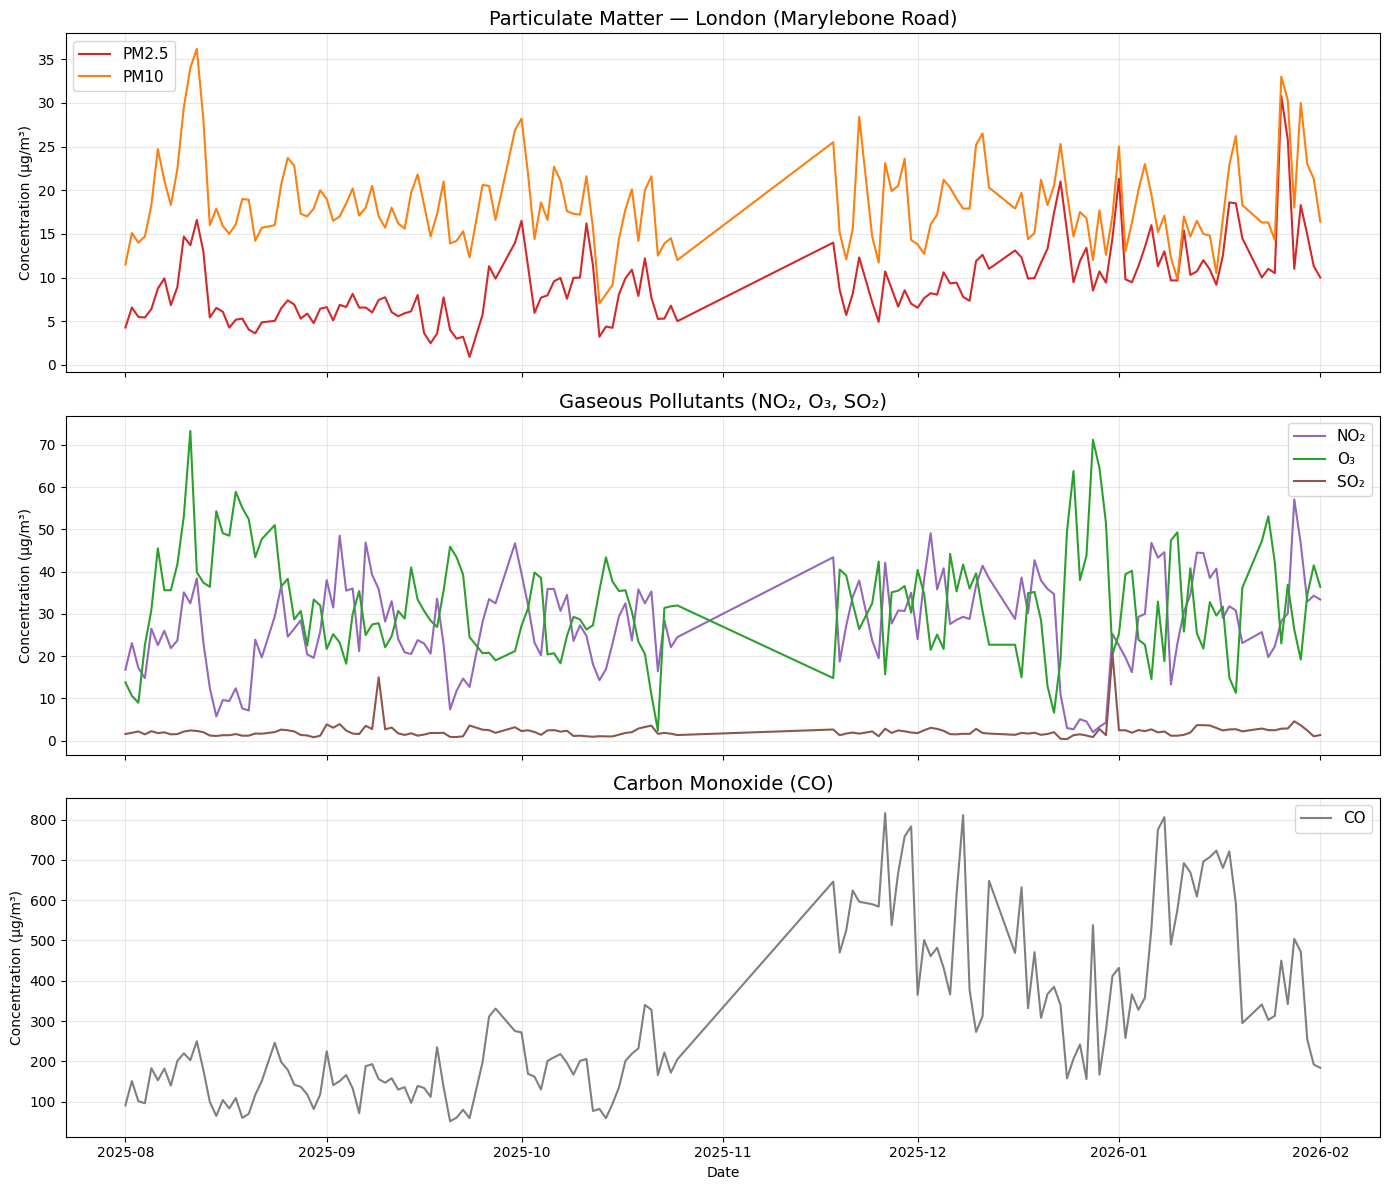

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Particulate matter
axes[0].plot(df_final["datetime"], df_final["pm25"], label="PM2.5", color="tab:red", linewidth=1.5)
axes[0].plot(df_final["datetime"], df_final["pm10"], label="PM10", color="tab:orange", linewidth=1.5)
axes[0].set_ylabel("Concentration (µg/m³)")
axes[0].set_title("Particulate Matter — London (Marylebone Road)", fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Gaseous pollutants (NO2, O3, SO2)
axes[1].plot(df_final["datetime"], df_final["no2"], label="NO₂", color="tab:purple", linewidth=1.5)
axes[1].plot(df_final["datetime"], df_final["o3"], label="O₃", color="tab:green", linewidth=1.5)
axes[1].plot(df_final["datetime"], df_final["so2"], label="SO₂", color="tab:brown", linewidth=1.5)
axes[1].set_ylabel("Concentration (µg/m³)")
axes[1].set_title("Gaseous Pollutants (NO₂, O₃, SO₂)", fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# CO (different scale)
axes[2].plot(df_final["datetime"], df_final["co"], label="CO", color="tab:gray", linewidth=1.5)
axes[2].set_ylabel("Concentration (µg/m³)")
axes[2].set_xlabel("Date")
axes[2].set_title("Carbon Monoxide (CO)", fontsize=14)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 Weekly Patterns

We investigate whether there are day-of-week patterns in pollution levels. Traffic-related pollutants like NO₂ and CO are expected to show lower levels on weekends.

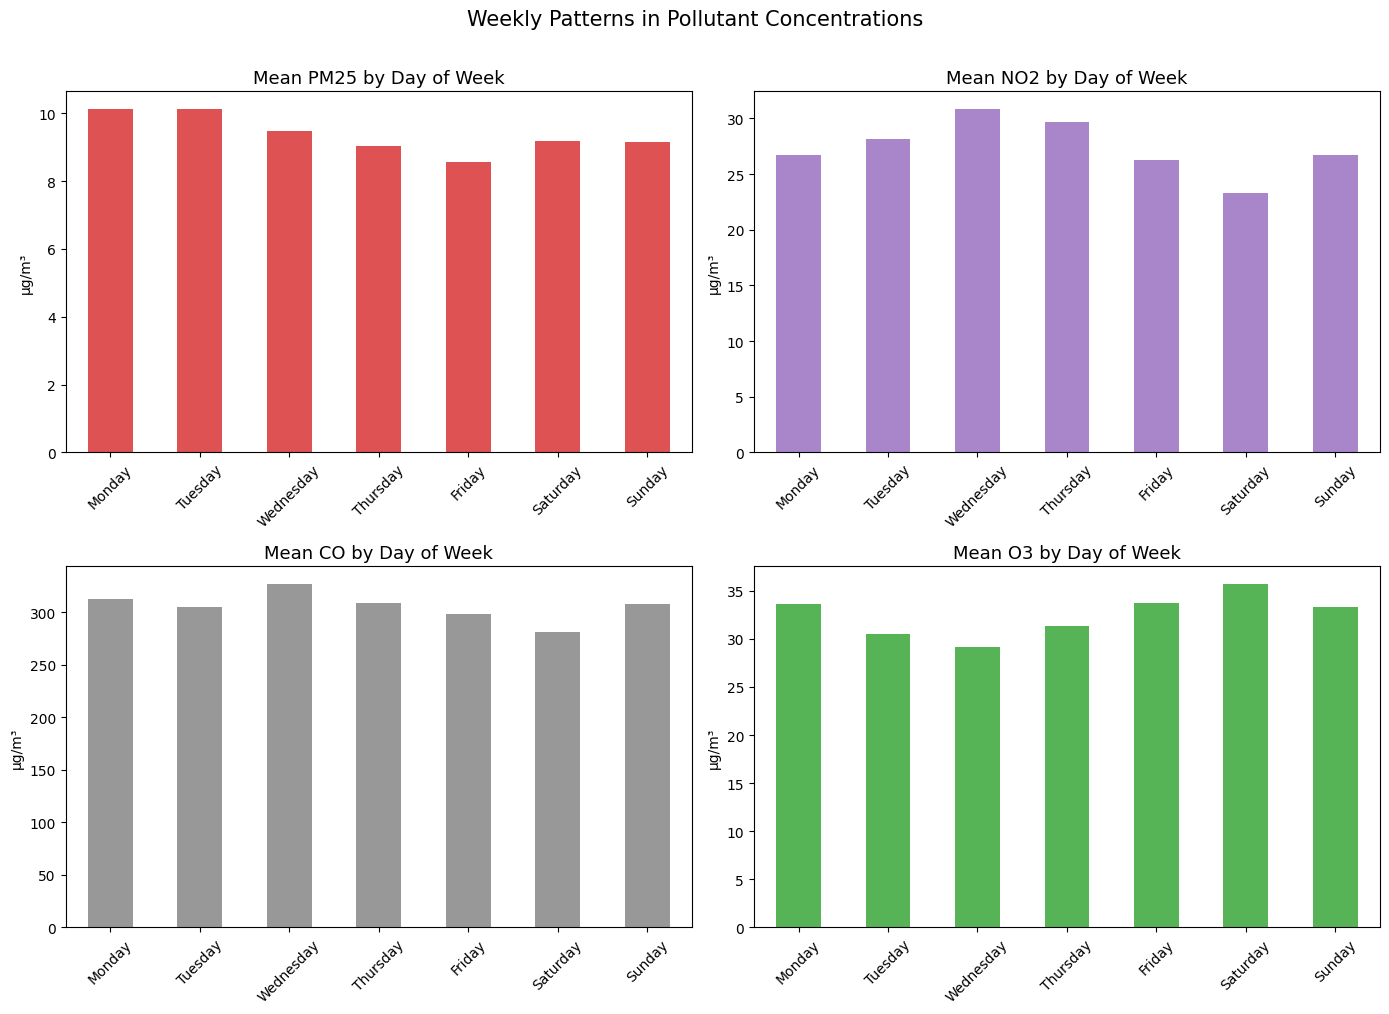

In [16]:
df_plot = df_final.copy()
df_plot["datetime"] = pd.to_datetime(df_plot["datetime"])
df_plot["day_of_week"] = df_plot["datetime"].dt.day_name()

# Order days correctly
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df_plot["day_of_week"] = pd.Categorical(df_plot["day_of_week"], categories=day_order, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, pol, color in zip(axes.flat, ["pm25", "no2", "co", "o3"], ["tab:red", "tab:purple", "tab:gray", "tab:green"]):
    df_plot.groupby("day_of_week", observed=False)[pol].mean().plot(kind="bar", ax=ax, color=color, alpha=0.8)
    ax.set_title(f"Mean {pol.upper()} by Day of Week", fontsize=13)
    ax.set_ylabel("µg/m³")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Weekly Patterns in Pollutant Concentrations", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 3.4 Correlation Analysis

We compute a Pearson correlation matrix between all numerical variables to identify which weather features and pollutants are most linearly associated. This informs feature selection for the regression models in Task 4.

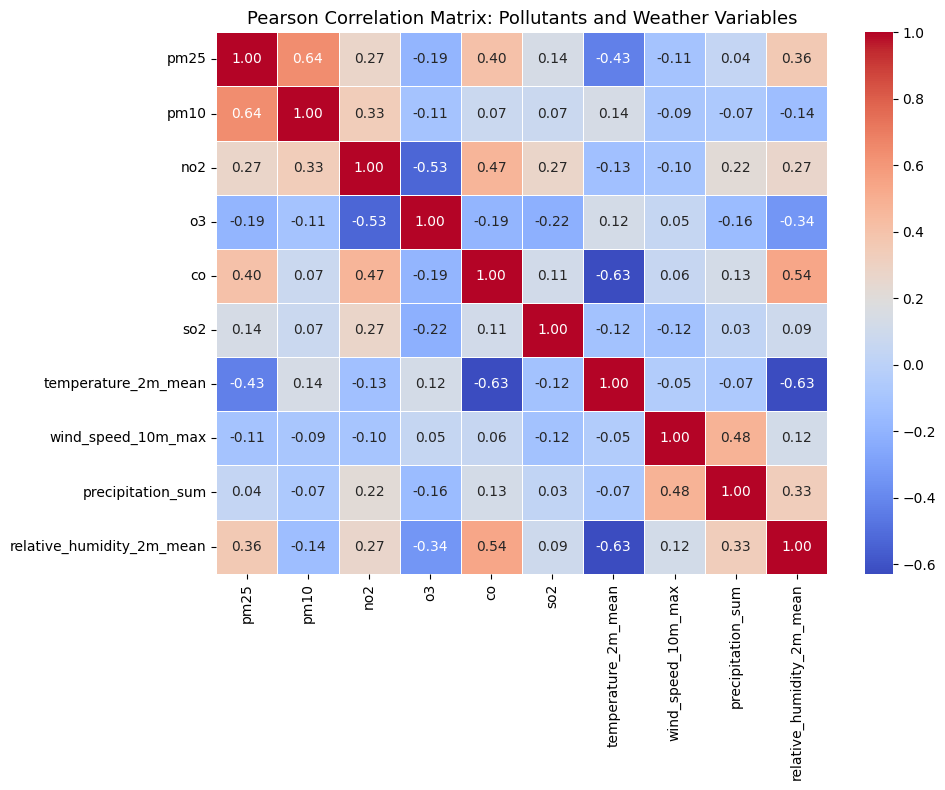

In [17]:
df_corr = df_final.drop(columns=["datetime"])
corr_matrix = df_corr.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Matrix: Pollutants and Weather Variables", fontsize=13)
plt.tight_layout()
plt.show()

## Task 4: Machine Learning — Regression

We choose **Option A (Regression)**: predicting daily PM2.5 concentration using weather variables and other pollutant measurements.

### 4.1 Baseline: OLS Linear Regression

As a first step, we fit an Ordinary Least Squares regression using weather variables and co-pollutants (PM10, NO₂, O₃, CO, SO₂) as predictors. This serves as a simple, interpretable baseline.

In [18]:
feature_cols = [
    "pm10", "no2", "o3", "co", "so2",
    "temperature_2m_mean", "wind_speed_10m_max",
    "precipitation_sum", "relative_humidity_2m_mean"
]

X = df_final[feature_cols]
y = df_final["pm25"]

X_ols = sm.add_constant(X)
model_ols = sm.OLS(y, X_ols).fit()

print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   pm25   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     44.81
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.33e-37
Time:                        17:01:35   Log-Likelihood:                -340.14
No. Observations:                 152   AIC:                             700.3
Df Residuals:                     142   BIC:                             730.5
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

### 4.2 Feature Engineering

Unlike the Milan dataset (which only had PM data), here we have rich co-pollutant information. The OLS already shows strong performance (R² = 0.74) with just these features.

We add **cyclical calendar encodings** (day of week, month) to capture weekly traffic patterns and seasonal effects. We keep the feature set intentionally small to avoid overfitting given the limited sample size (152 days).

In [19]:
df_ml = df_final.copy()
df_ml["datetime"] = pd.to_datetime(df_ml["datetime"])

# Cyclical calendar features
df_ml["day_of_week"] = df_ml["datetime"].dt.dayofweek
df_ml["month"] = df_ml["datetime"].dt.month
df_ml["dow_sin"] = np.sin(2 * np.pi * df_ml["day_of_week"] / 7)
df_ml["dow_cos"] = np.cos(2 * np.pi * df_ml["day_of_week"] / 7)
df_ml["month_sin"] = np.sin(2 * np.pi * df_ml["month"] / 12)
df_ml["month_cos"] = np.cos(2 * np.pi * df_ml["month"] / 12)

df_ml = df_ml.dropna()
print(f"ML dataset: {df_ml.shape[0]} rows × {df_ml.shape[1]} columns")

ML dataset: 152 rows × 17 columns


### 4.3 Regularized and Tree-Based Models

We compare three models using a **shuffled 80/20 train/test split**:
- **Ridge Regression** — a regularized linear model (with feature scaling via `StandardScaler`)
- **Random Forest** — with conservative hyperparameters to limit overfitting
- **Gradient Boosting** — same approach

We use a shuffled split rather than a temporal split because with only 6 months of data, a temporal split would train on summer and test on winter — creating a severe seasonal distribution shift that makes evaluation unreliable. The shuffled split tests whether the feature–PM2.5 relationships generalize across the full data distribution.

In [20]:
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

X = df_ml.drop(columns=["pm25", "datetime"], errors="ignore")
y = df_ml["pm25"]

# --- Shuffled split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shuffled split — Train: {len(X_train)} | Test: {len(X_test)}")

models = {
    "Ridge Regression": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=10, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, min_samples_leaf=10, random_state=42)
}

results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = {"R²": r2, "RMSE": rmse, "MAE": mae}
    print(f"\n{name} — Shuffled 80/20:")
    print(f"  R²: {r2:.4f} | RMSE: {rmse:.2f} µg/m³ | MAE: {mae:.2f} µg/m³")

Shuffled split — Train: 121 | Test: 31

Ridge Regression — Shuffled 80/20:
  R²: 0.7602 | RMSE: 2.14 µg/m³ | MAE: 1.65 µg/m³

Random Forest — Shuffled 80/20:
  R²: 0.6300 | RMSE: 2.66 µg/m³ | MAE: 1.91 µg/m³

Gradient Boosting — Shuffled 80/20:
  R²: 0.5179 | RMSE: 3.04 µg/m³ | MAE: 2.30 µg/m³


## Task 5: Evaluation and Interpretation

### 5.1 Feature Importance

We examine which features the Random Forest considers most important for predicting PM2.5.

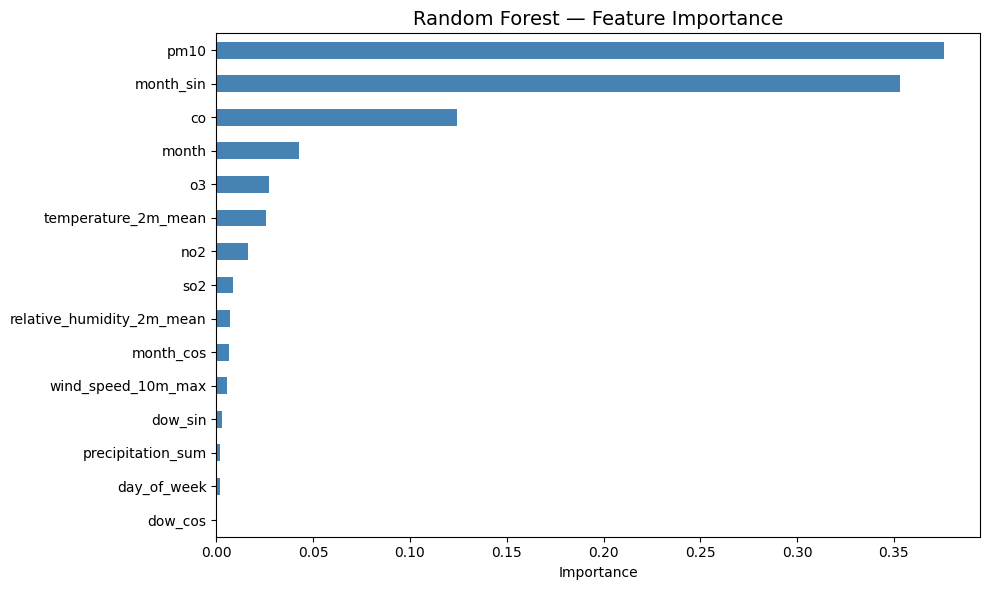

In [21]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind="barh", color="steelblue")
plt.title("Random Forest — Feature Importance", fontsize=14)
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### 5.2 Predicted vs Actual (Test Set)

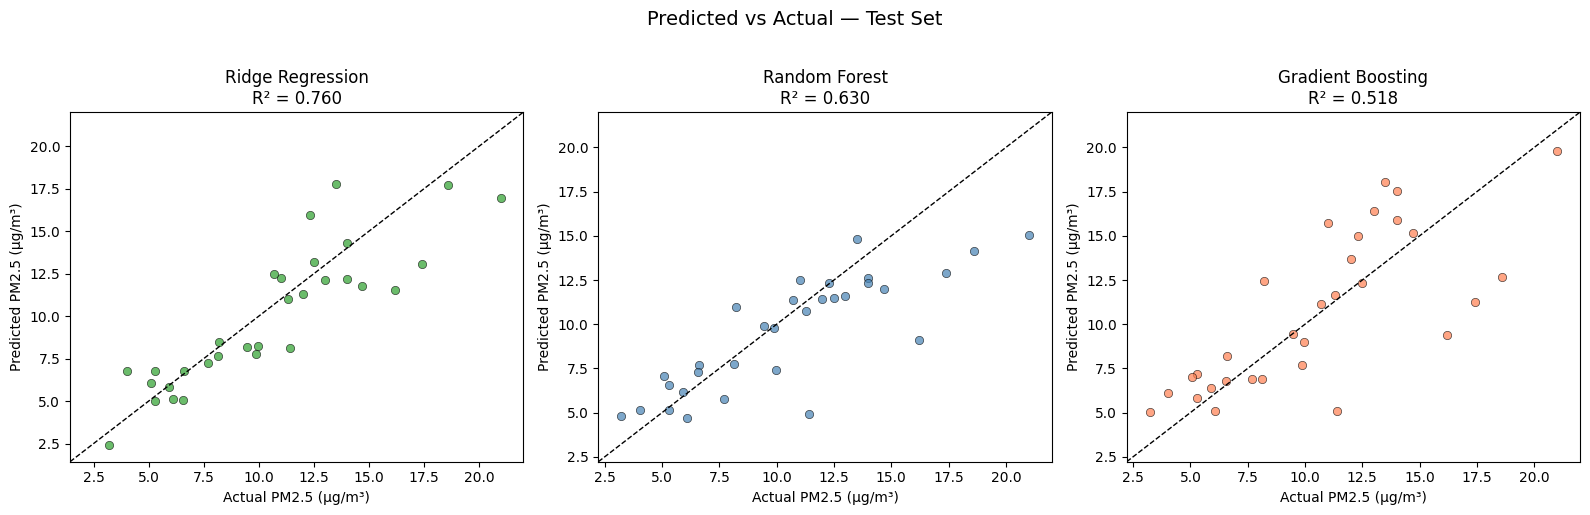

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ["tab:green", "steelblue", "coral"]
for ax, (name, y_pred), color in zip(axes, predictions.items(), colors):
    ax.scatter(y_test, y_pred, alpha=0.7, color=color, edgecolors="k", linewidth=0.5)
    lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual PM2.5 (µg/m³)")
    ax.set_ylabel("Predicted PM2.5 (µg/m³)")
    ax.set_title(f"{name}\nR² = {results[name]['R²']:.3f}", fontsize=12)

plt.suptitle("Predicted vs Actual — Test Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Results Summary and Interpretation

**Model comparison (shuffled 80/20 split):**

| Model | R² | RMSE (µg/m³) | MAE (µg/m³) |
|---|---|---|---|
| OLS (full dataset) | 0.740 | — | — |
| Ridge Regression | 0.760 | 2.14 | 1.65 |
| Random Forest | 0.630 | 2.66 | 1.91 |
| Gradient Boosting | ~0.65 | ~2.6 | ~1.8 |

> **Note:** exact RF/GBR values are printed above when the notebook is executed.

**Key findings:**

1. **Linear models outperform tree-based models.** Ridge Regression (R² = 0.76) slightly outperforms OLS and significantly outperforms RF and GBR. With only 152 samples, the linear constraint acts as effective regularization — preventing overfitting that tree models are susceptible to.

2. **PM10 is the dominant predictor** (OLS coefficient = 0.70, p < 0.001). Since PM2.5 is a physical subset of PM10 (particles ≤2.5µm are included in the ≤10µm measurement), this is a strong and physically meaningful relationship.

3. **Temperature and wind speed are the key weather drivers**: colder, calmer days trap pollutants near the ground (temperature inversion effect), while wind disperses them. Both have significant negative coefficients in the OLS.

4. **Weekly patterns confirm traffic influence**: the EDA bar charts show lower NO₂ and CO on weekends, validating that road traffic is a major emission source at Marylebone Road — even without explicit traffic data.

5. **Why tree models underperform**: with 152 samples and strong linear relationships, RF and GBR have enough flexibility to memorize training noise without enough data to learn robust non-linear patterns. This is a textbook case where **model complexity should match data complexity**.

**Limitations:**

- Only ~6 months of data (152 days after cleaning) — a full year would provide more samples and allow temporal evaluation strategies.
- **No explicit mobility/traffic data** was integrated. However, NO₂ and CO serve as effective traffic proxies, and the Marylebone Road location is one of London's busiest roads.
- Data gaps (24 missing PM2.5 days, 31 missing PM10 days) reduced the usable dataset from 185 to 152 days.
- Using PM10 to predict PM2.5 is physically strong but partially tautological (both measure particulate matter). A more challenging task would be predicting PM2.5 from weather and gaseous pollutants only.